# Data Pre-Processing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats


excel_file = "/Users/lojainabdulla/Downloads/Crash Risk Data (1).xls"

# Load the data
df = pd.read_excel(excel_file)
df.head()

,gvkey,fyear,sic,big4,modified,lnmarket_val,lntotal_assets,asset_growth,liability_growth,sales_growth,...,lit,z_score,netfilesize,n_words_den3,n_negative_den3,n_positive_den3,n_uncertainty_den3,n_litigious_den3,crash_new320Plus,ncskew_new_plus
0,10884,1993,100,1,0,6.324117,7.915988,-0.048556,-0.030367,-0.069889,...,0,1.341682,450656,60503,563,226,405,1883,0,-0.760525
1,10390,1994,100,1,1,5.025090,3.804883,-0.042524,-0.235625,-0.082085,...,0,13.269255,190514,20653,244,108,180,457,0,-0.774498
2,8596,1994,100,1,1,7.898852,7.133631,0.026246,-0.063346,0.100678,...,0,7.983232,91626,10501,88,133,104,63,0,0.290179
3,2812,1994,100,0,0,7.221101,8.255486,0.136002,0.220105,0.119820,...,0,1.861746,415553,51758,584,321,520,1466,0,-0.855944
4,14881,1994,100,1,1,5.130932,5.765191,0.008217,-0.024667,0.097770,...,0,2.181140,362277,48629,659,430,281,1499,0,-0.140956


In [42]:
!pip install scipy



[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: pip install --upgrade pip


In [13]:
print(f"There are duplicated data: {any(df.duplicated())}")
print(f"There are missing values: {df.isnull().values.any()}")

There are duplicated data: False
There are missing values: False


In [ ]:
#Displaying imbalanced panel data
is_balanced = df.groupby('gvkey').count()['fyear'] 


gvkey
1004      23
1013      16
1034      12
1036       1
1043       3
          ..
289735     1
294524     5
315318     1
316056     2
317264     1
Name: fyear, Length: 7861, dtype: int64

In [18]:
if is_balanced.nunique() > 1:
    print("The data is imbalanced.")

The data is imbalanced.


In [21]:
# Display the full descriptive statistics using to_string()
print(df.describe(include='all').to_string())


               gvkey         fyear           sic          big4      modified  lnmarket_val  lntotal_assets  asset_growth  liability_growth  sales_growth        mtb_at          roa2       lev_mkt           age           lit       z_score   netfilesize  n_words_den3  n_negative_den3  n_positive_den3  n_uncertainty_den3  n_litigious_den3  crash_new320Plus  ncskew_new_plus
count   61796.000000  61796.000000  61796.000000  61796.000000  61796.000000  61796.000000    61796.000000  61796.000000      61796.000000  61796.000000  61796.000000  61796.000000  61796.000000  61796.000000  61796.000000  61796.000000  6.179600e+04  6.179600e+04     61796.000000     61796.000000        61796.000000      61796.000000      61796.000000     61796.000000
mean    44585.330766   2004.041572   4552.068014      0.744757      0.286718      5.903158        5.864157      0.197661          0.331368      0.649182      1.717303     -0.022121      0.501720     25.135705      0.340022      5.274851  3.366251e+05  4.32

In [22]:
# Skewness
skewness = df.skew()
print("Skewness:\n", skewness)

# Kurtosis
kurtosis = df.kurtosis()
print("\nKurtosis:\n", kurtosis)


Skewness:
 gvkey                   1.507774
fyear                   0.202539
sic                     0.518297
big4                   -1.122771
modified                0.943274
lnmarket_val            0.190601
lntotal_assets          0.233756
asset_growth          100.858425
liability_growth      209.634118
sales_growth          136.101296
mtb_at                235.510827
roa2                  -12.333106
lev_mkt                43.915474
age                     0.837503
lit                     0.675433
z_score               188.763372
netfilesize             5.072716
n_words_den3            5.082462
n_negative_den3         4.472660
n_positive_den3         3.467317
n_uncertainty_den3      2.048873
n_litigious_den3        7.036355
crash_new320Plus        1.664793
ncskew_new_plus         0.534854
dtype: float64

Kurtosis:
 gvkey                     1.318800
fyear                    -1.114754
sic                      -0.569439
big4                     -0.739409
modified                 -1.11

Data Visualisation


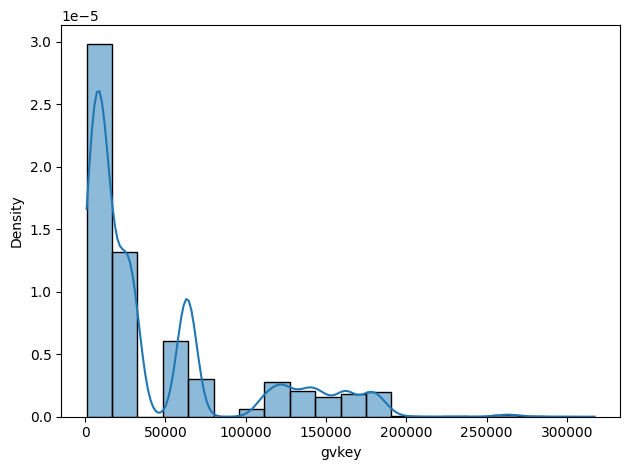

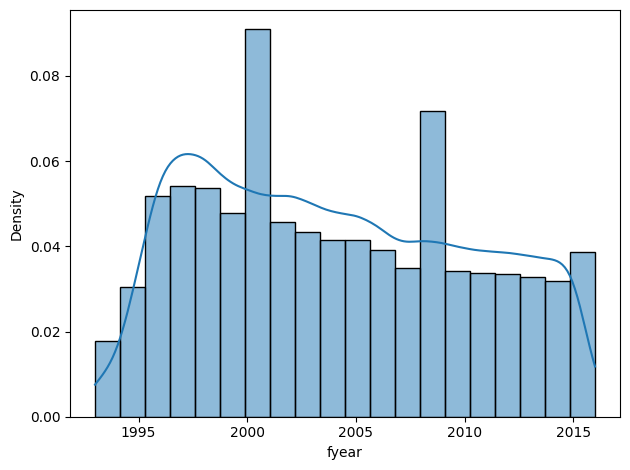

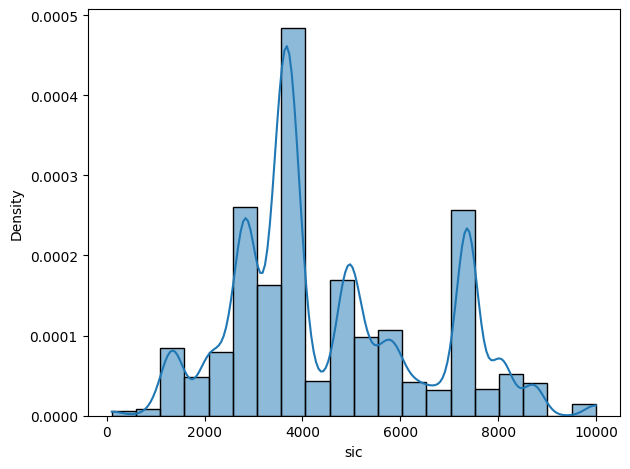

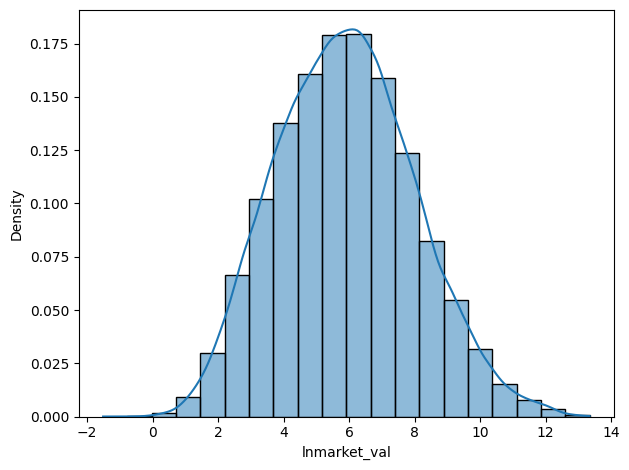

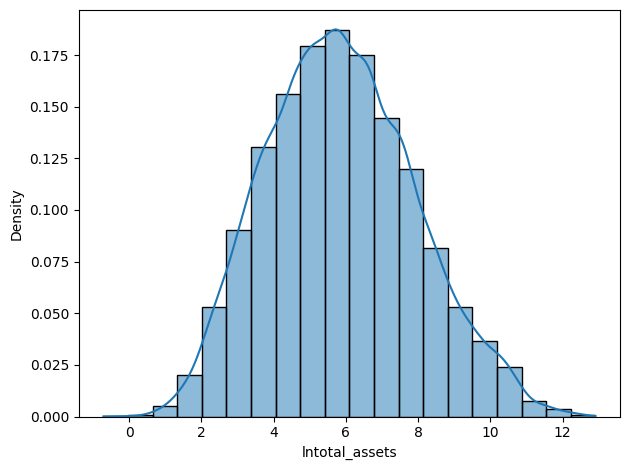

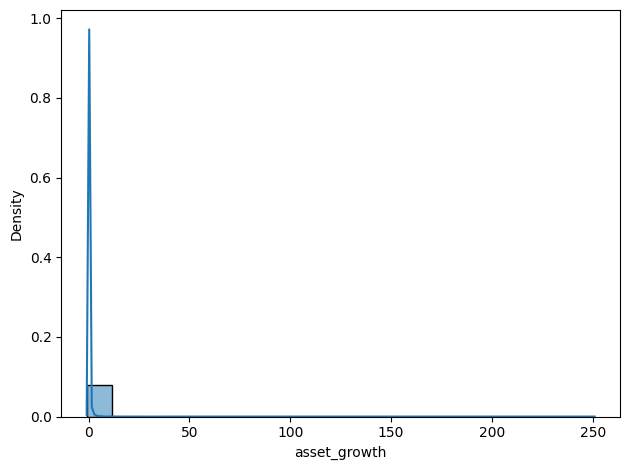

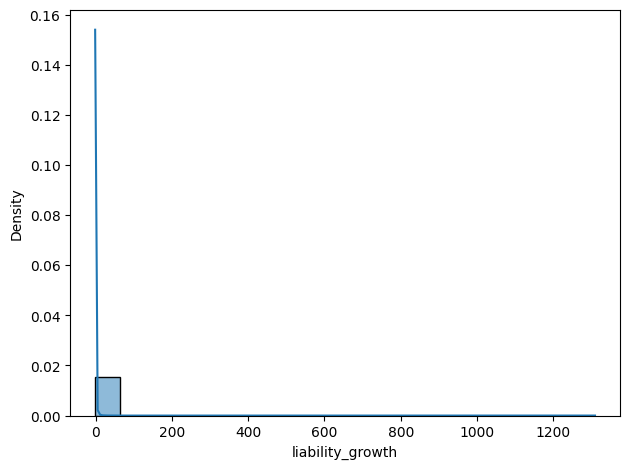

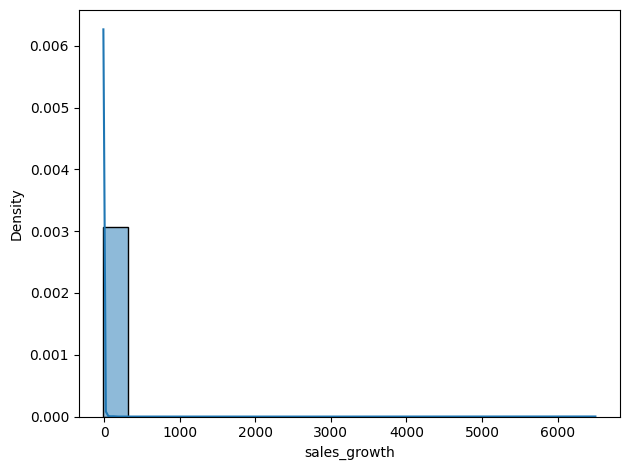

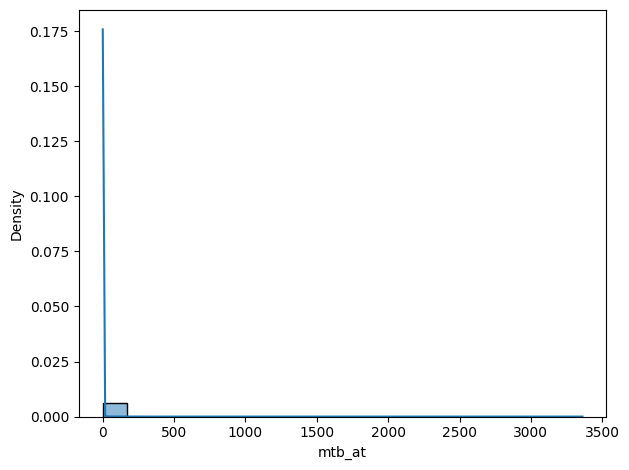

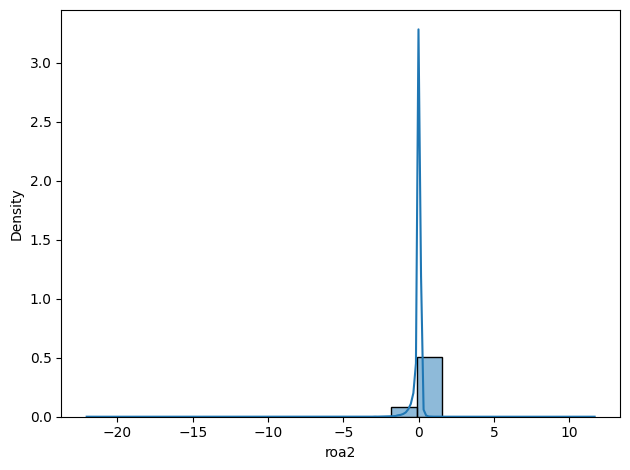

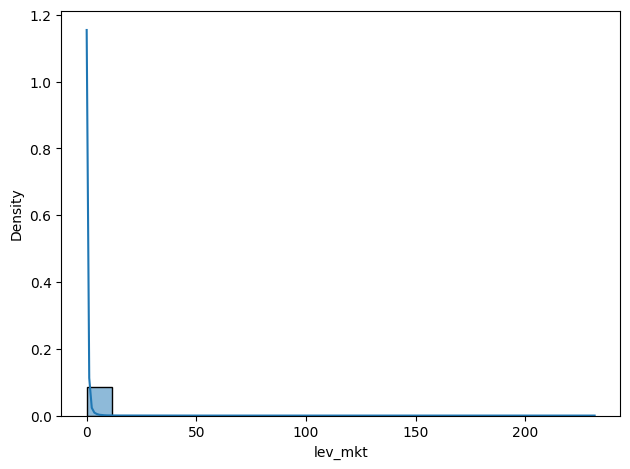

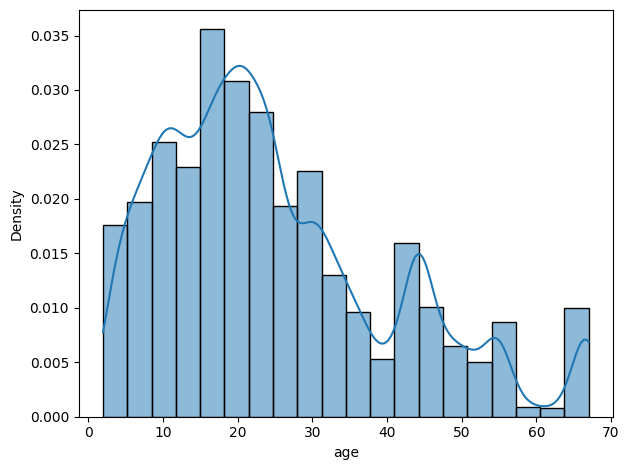

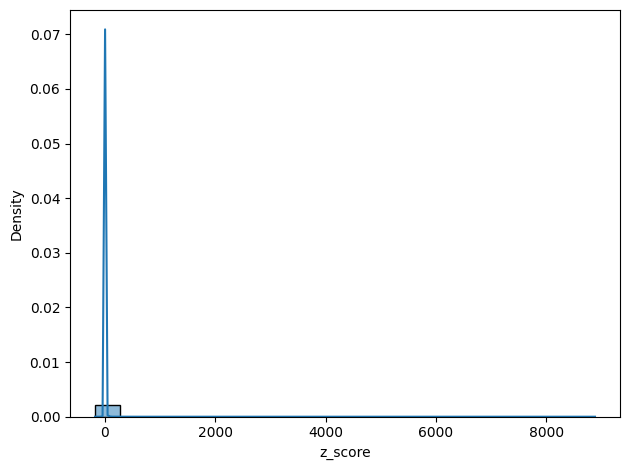

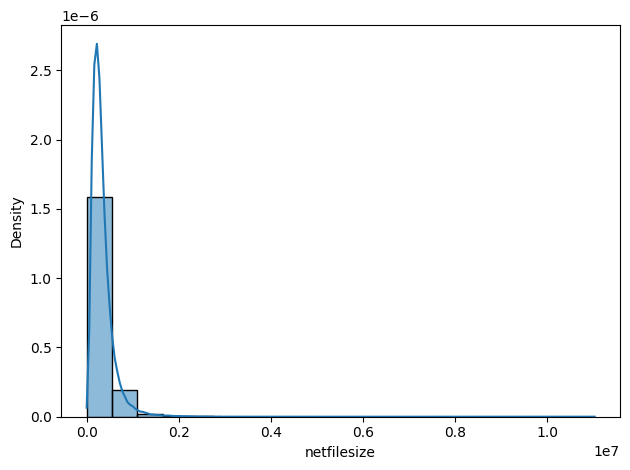

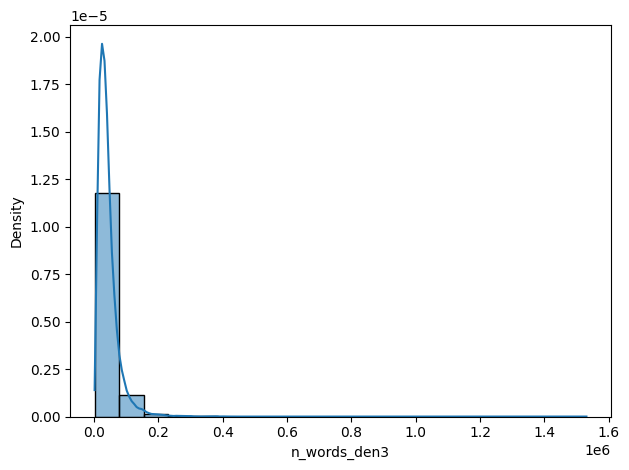

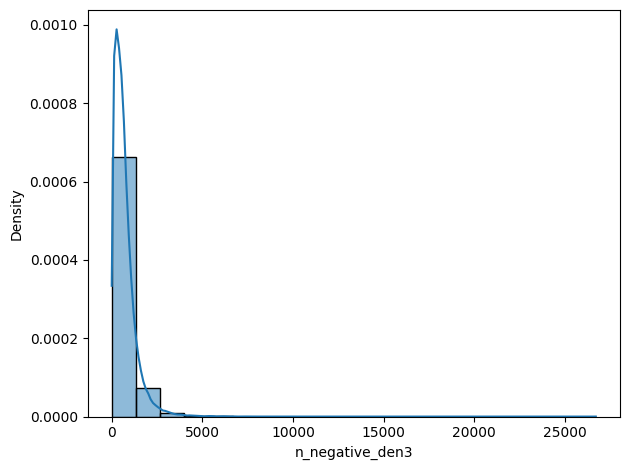

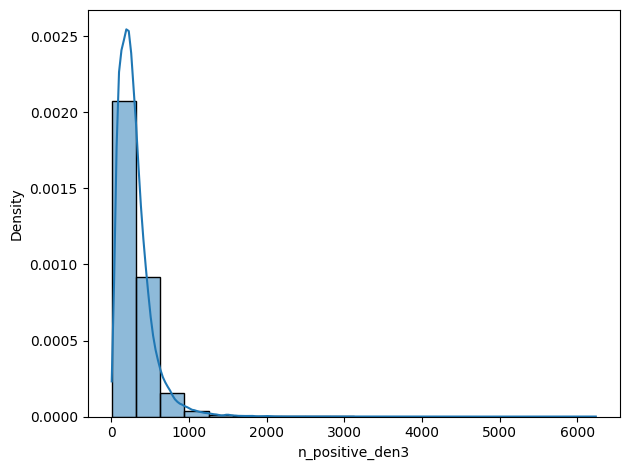

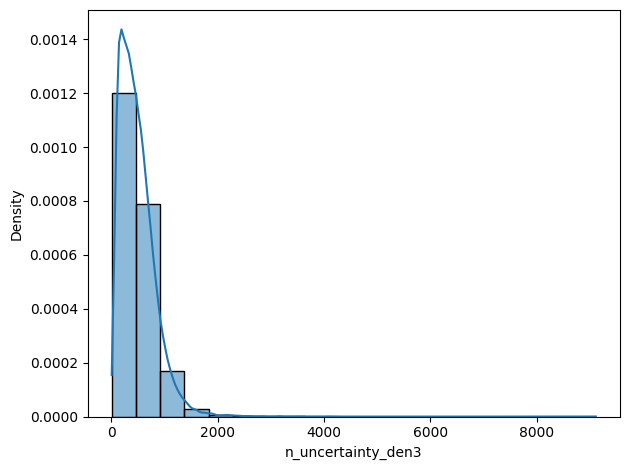

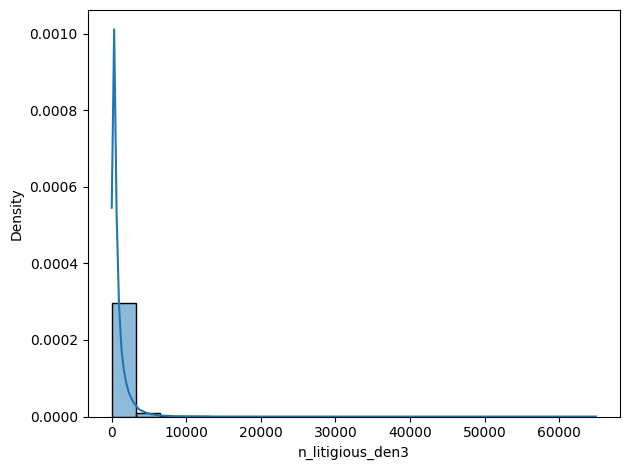

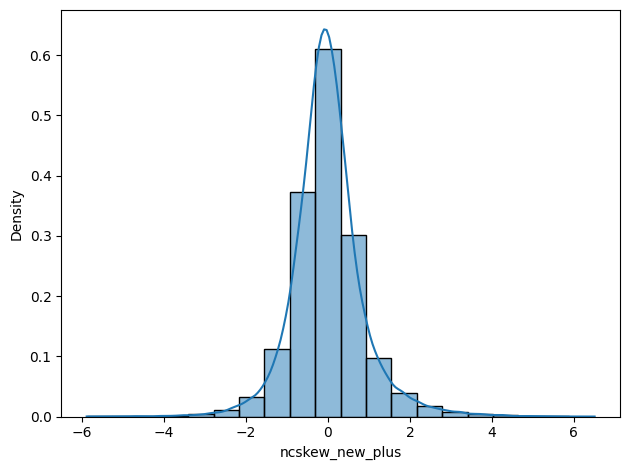

/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_12863/822150678.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")
/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_12863/822150678.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")
/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_12863/822150678.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")
/var

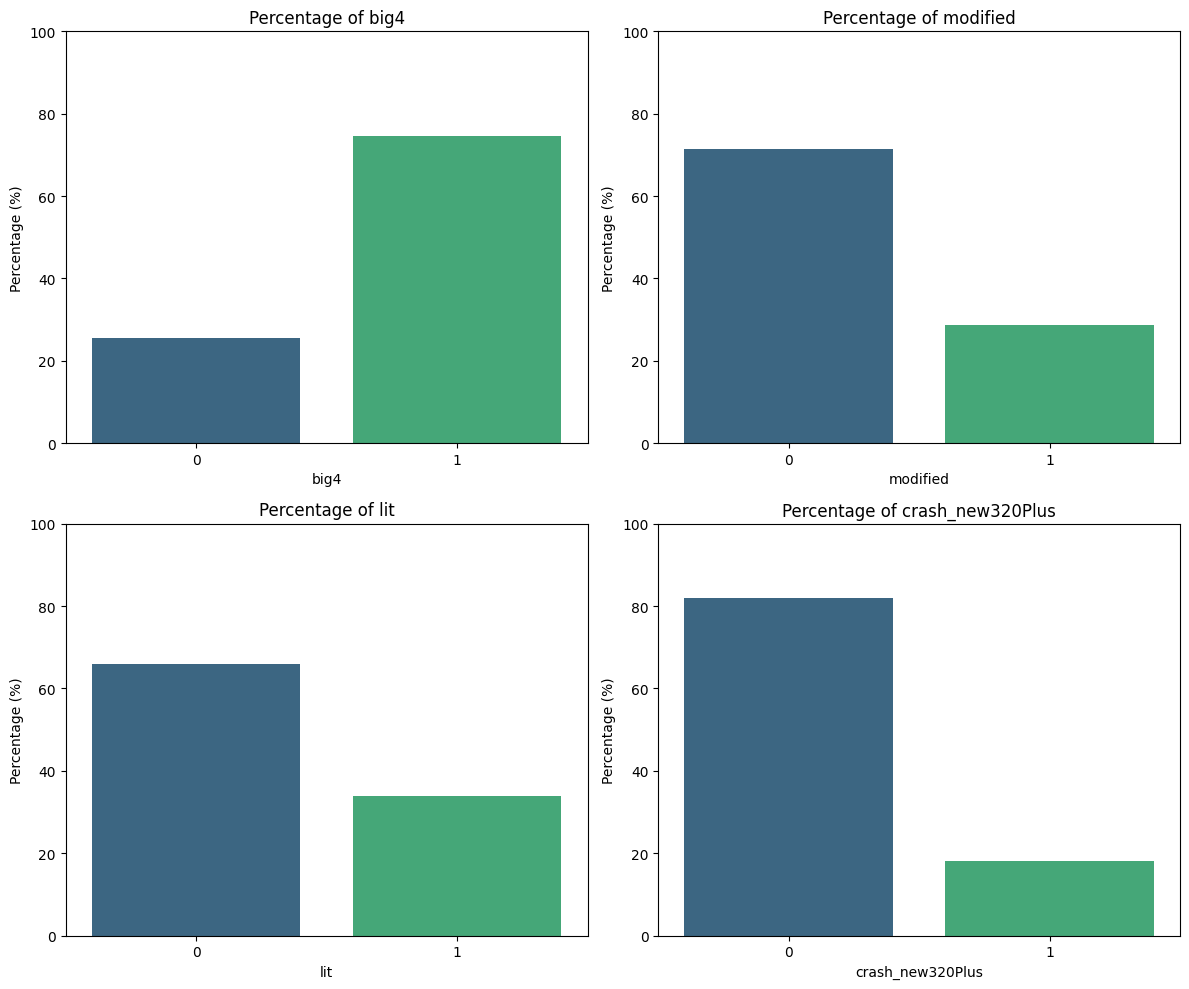

In [24]:
binary_columns = ['big4', 'modified','lit', 'crash_new320Plus' ]
numerical_cols = ['gvkey', 'fyear', 'sic','lnmarket_val', 'lntotal_assets', 'asset_growth', 
                  'liability_growth', 'sales_growth', 'mtb_at', 'roa2', 'lev_mkt', 'age','z_score',
                  'netfilesize','n_words_den3','n_negative_den3', 'n_positive_den3',
                  'n_uncertainty_den3','n_litigious_den3', 'ncskew_new_plus'   ]
for col in numerical_cols:
    sns.histplot(df[col], kde=True, stat='density', bins=20)
    plt.tight_layout()
    plt.show()
# Set up the matplotlib figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for ax, col in zip(axes, binary_columns):
    # Calculate percentage
    pct = df[col].value_counts(normalize=True) * 100
    # Create bar plot
    sns.barplot(x=pct.index, y=pct.values, ax=ax, palette="viridis")
    # Set titles and labels
    ax.set_title(f'Percentage of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()


In [11]:
columns_to_remove_outliers = ['asset_growth', 'liability_growth','sales_growth','mtb_at', 'roa2', 'lev_mkt','z_score',
                'netfilesize','n_words_den3','n_negative_den3', 'n_positive_den3',
                'n_uncertainty_den3','n_litigious_den3']
df_no_outliers = df[columns_to_remove_outliers]
df_no_outliers.head()

,asset_growth,liability_growth,sales_growth,mtb_at,roa2,lev_mkt,z_score,netfilesize,n_words_den3,n_negative_den3,n_positive_den3,n_uncertainty_den3,n_litigious_den3
0,-0.048556,-0.030367,-0.069889,0.203544,-0.018638,2.922903,1.341682,450656,60503,563,226,405,1883
1,-0.042524,-0.235625,-0.082085,3.387890,0.033994,0.020088,13.269255,190514,20653,244,108,180,457
2,0.026246,-0.063346,0.100678,2.149469,0.169667,0.029974,7.983232,91626,10501,88,133,104,63
3,0.136002,0.220105,0.119820,0.355445,0.017638,1.175678,1.861746,415553,51758,584,321,520,1466
4,0.008217,-0.024667,0.097770,0.530328,0.034483,0.769027,2.181140,362277,48629,659,430,281,1499


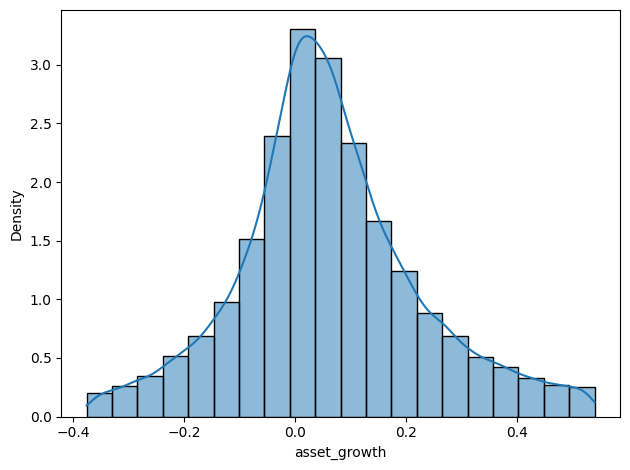

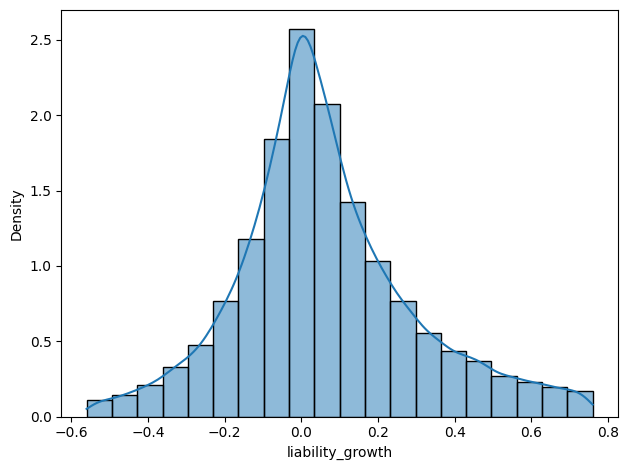

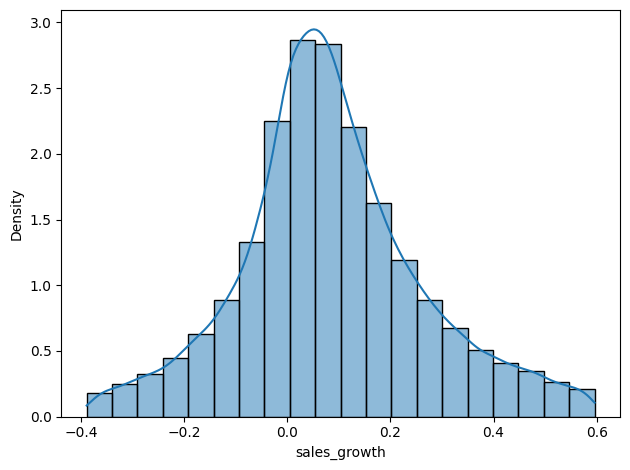

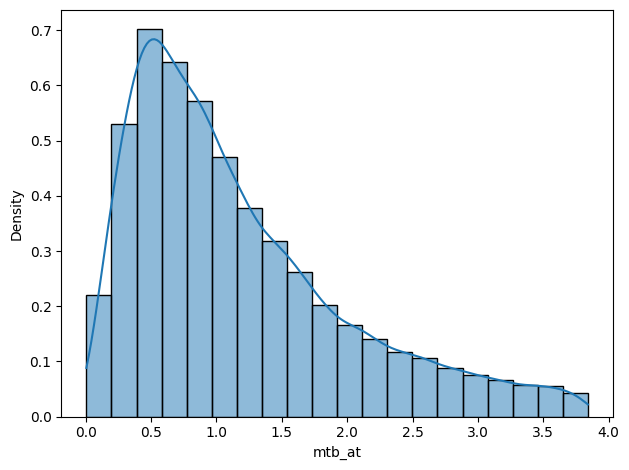

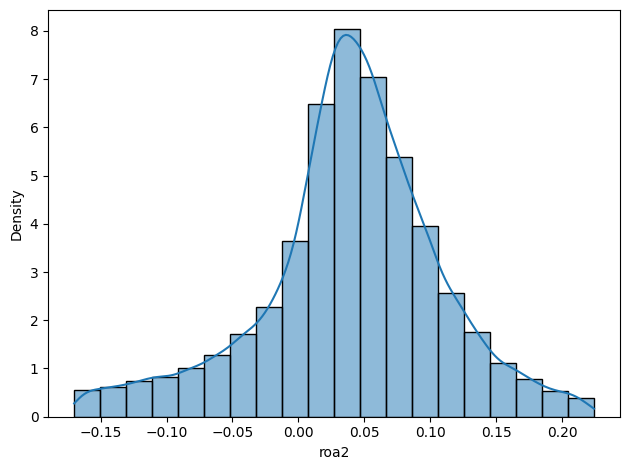

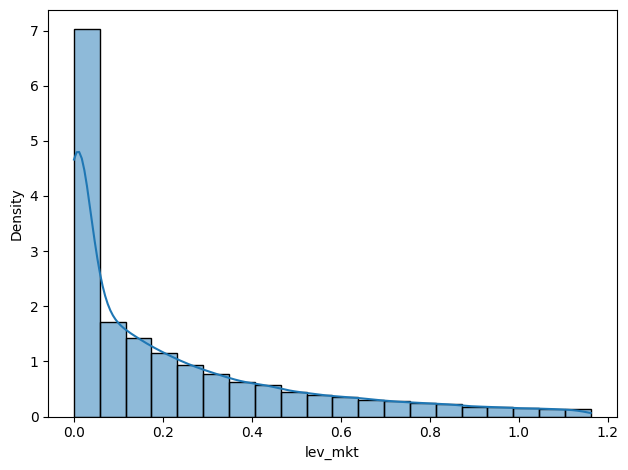

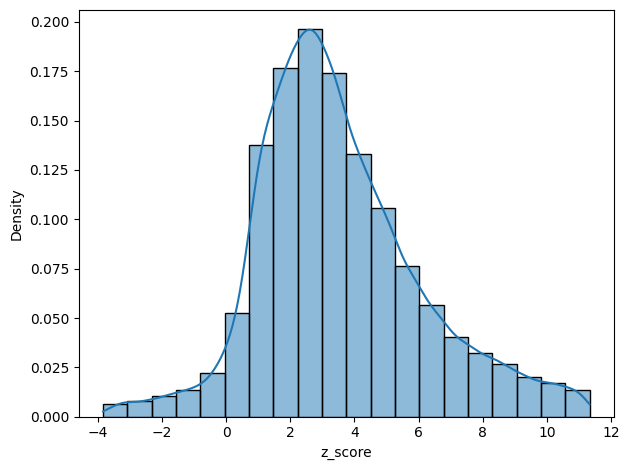

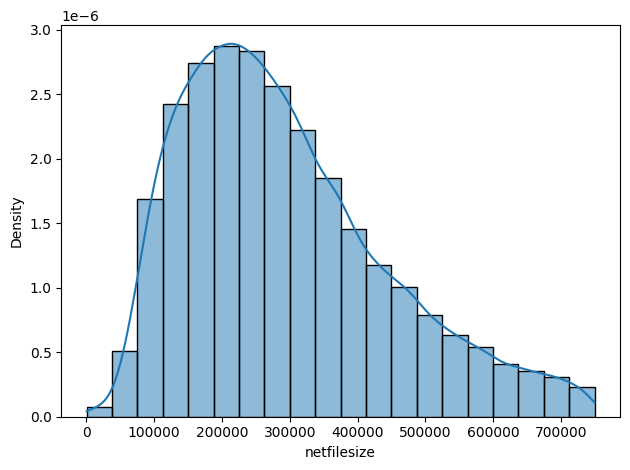

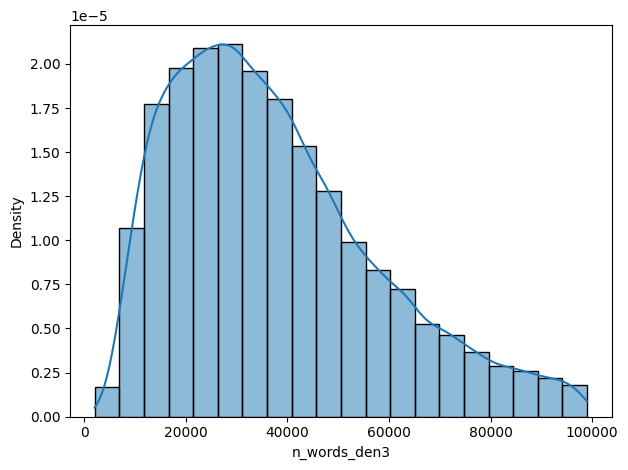

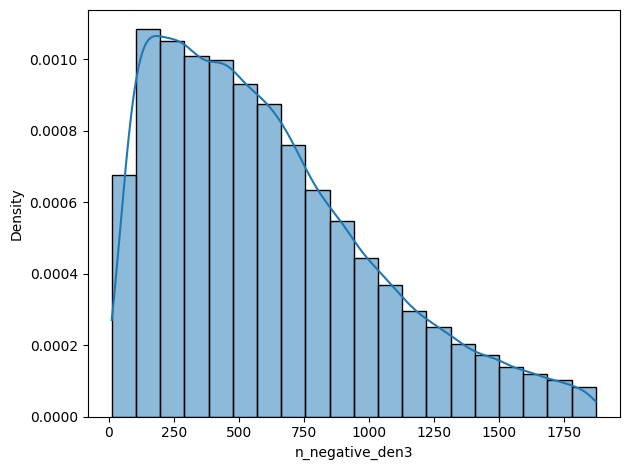

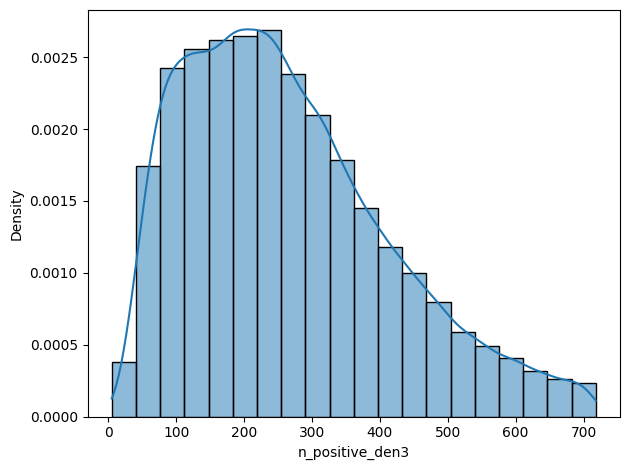

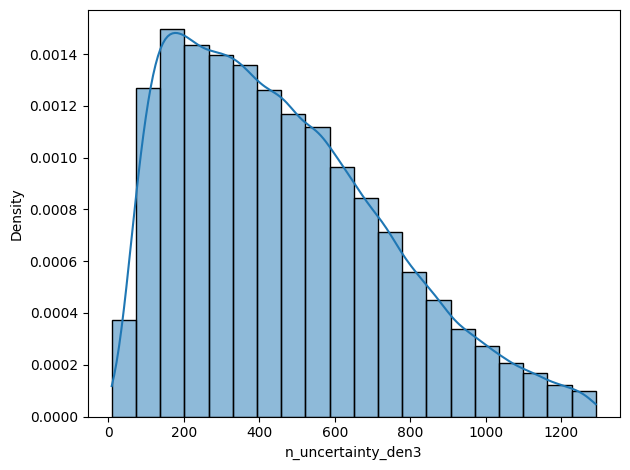

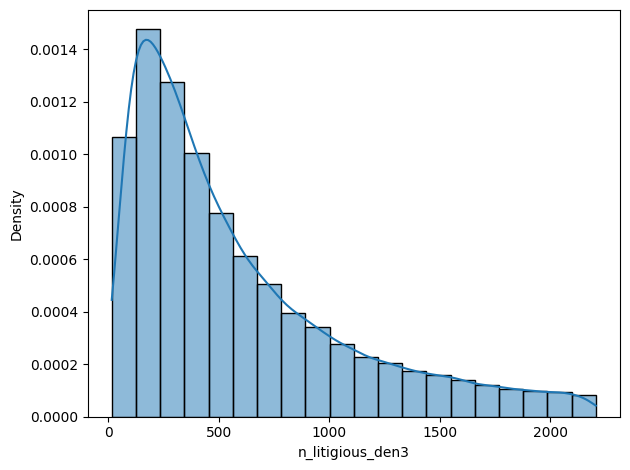

In [12]:
for col in columns_to_remove_outliers:
    df_no_outliers = df[columns_to_remove_outliers]
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    df_no_outliers = df_no_outliers[(df_no_outliers[col] >= Q1 - 1.5 * IQR) & (df_no_outliers[col] <= Q3 + 1.5 * IQR)]
    sns.histplot(df_no_outliers[col], kde=True, stat='density', bins=20)
    plt.tight_layout()
    plt.show()    
    

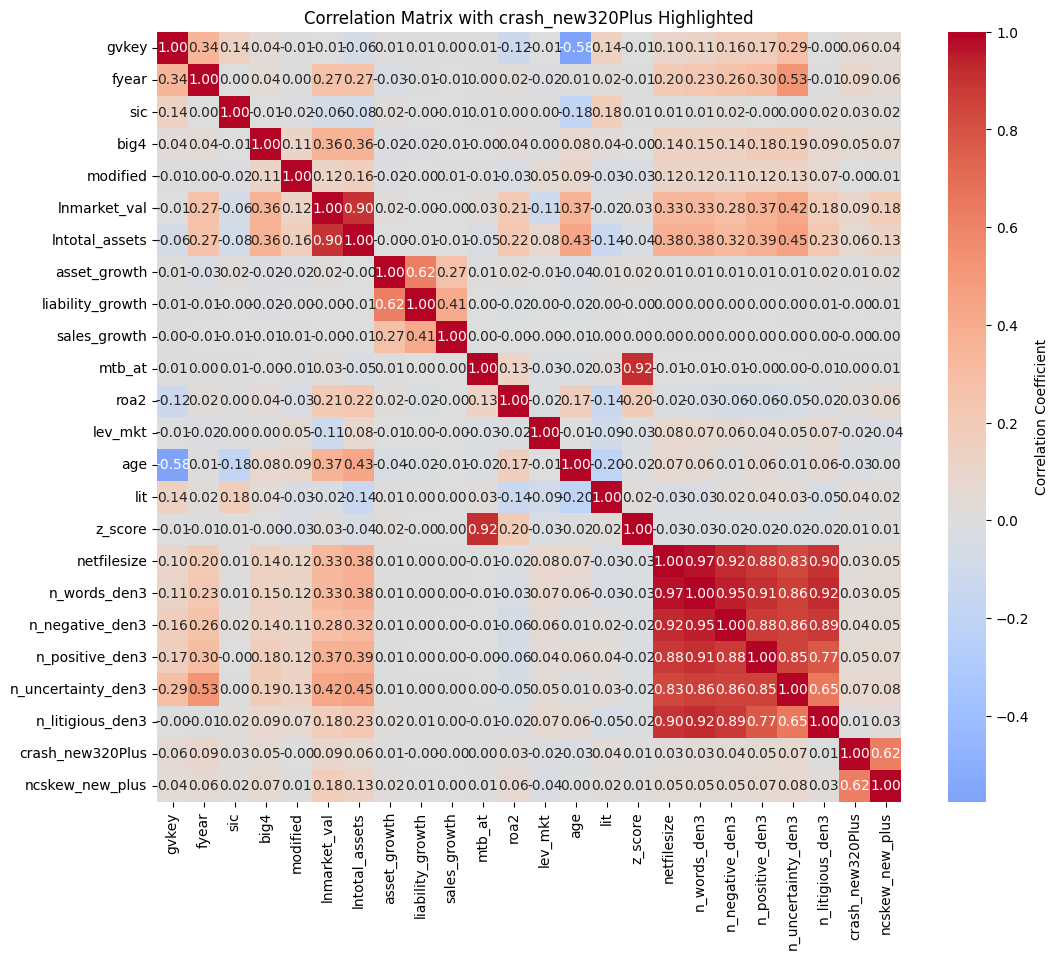

In [64]:
#Create heatmap for all variables correlation to predictive variable

df_numerical = df.select_dtypes(include=[np.number])
corr_matrix = df_numerical.corr()
# Select correlations with 'crash_new320Plus'
crash_correlations = corr_matrix['crash_new320Plus'].drop('crash_new320Plus') 
crash_correlations_sorted = crash_correlations.sort_values(ascending=False)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix with crash_new320Plus Highlighted')
plt.show()


/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_30154/4048381694.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=crash_correlations_sorted.values, y=crash_correlations_sorted.index, palette=colors)


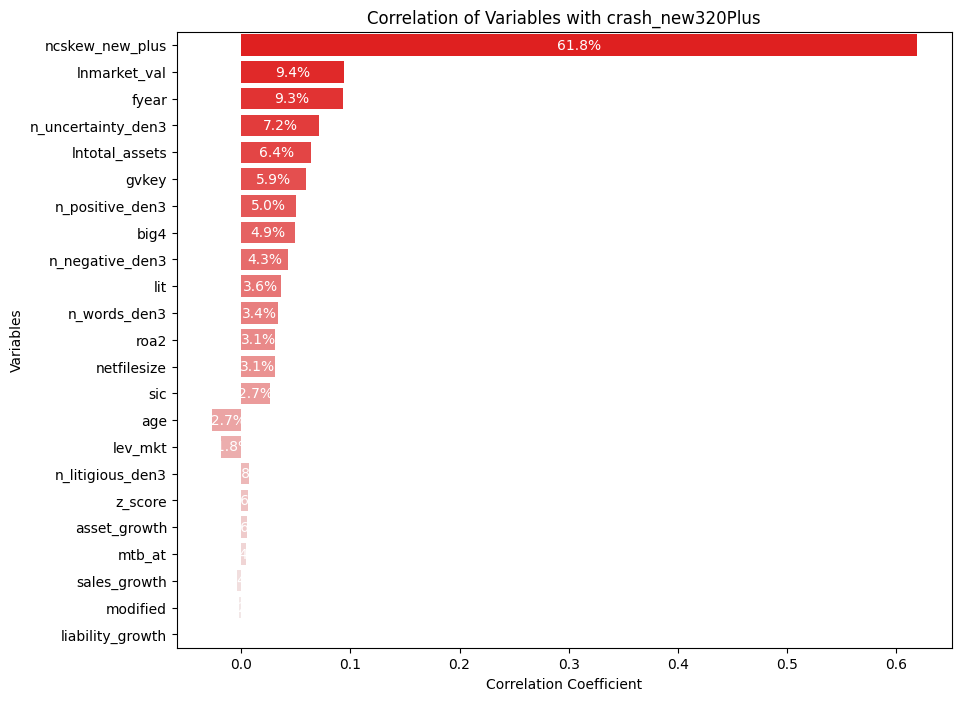

In [ ]:
# Heat map for all variable correlations against crash_new320Plus (predictive variable)
corrs = df.corr()['crash_new320Plus'].drop('crash_new320Plus')
crash_correlations_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)

colors = sns.light_palette("red", n_colors=len(crash_correlations_sorted), reverse=True)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=crash_correlations_sorted.values, y=crash_correlations_sorted.index, palette=colors)

for i, val in enumerate(crash_correlations_sorted.values):
    ax.text(val/2, i, f'{val*100:.1f}%', va='center', ha='center', color='white', fontsize=10)

plt.title('Correlation of Variables with crash_new320Plus')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')
plt.show()


/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_30154/474222958.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ncskew_correlations_sorted.values, y=ncskew_correlations_sorted.index, palette=colors)


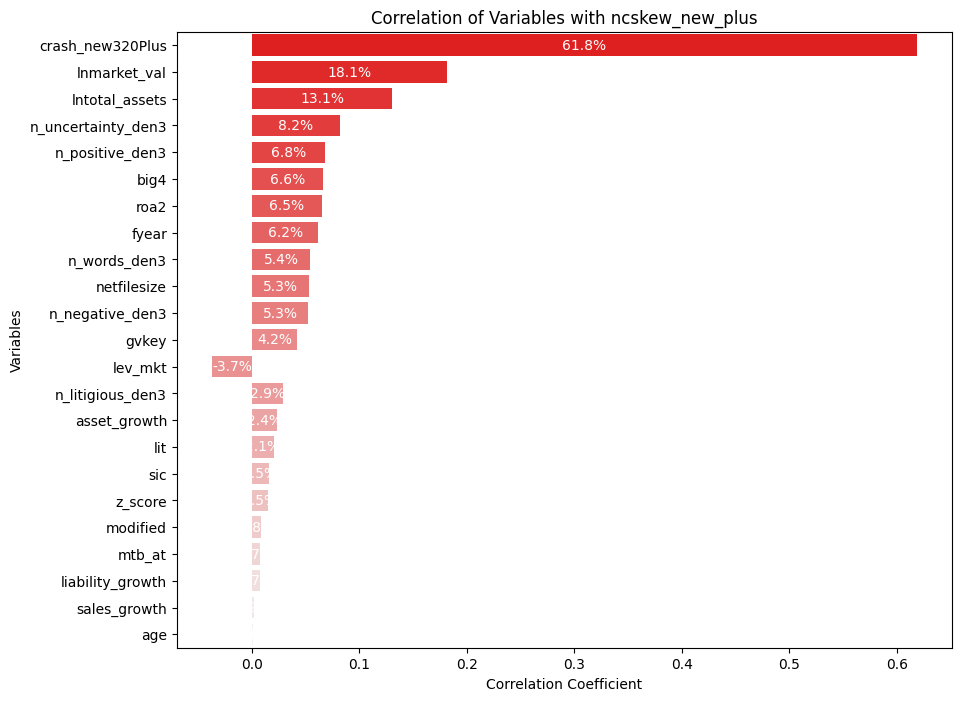

In [29]:
# Heat map for variable correlations with ncskew_new_plus (predictive variable)

corrs = df.corr()['ncskew_new_plus'].drop('ncskew_new_plus')
ncskew_correlations_sorted = corrs.reindex(corrs.abs().sort_values(ascending=False).index)

colors = sns.light_palette("red", n_colors=len(ncskew_correlations_sorted), reverse=True)

plt.figure(figsize=(10, 8))
ax = sns.barplot(x=ncskew_correlations_sorted.values, y=ncskew_correlations_sorted.index, palette=colors)

for i, val in enumerate(ncskew_correlations_sorted.values):
    ax.text(val/2, i, f'{val*100:.1f}%', va='center', ha='center', color='white', fontsize=10)

plt.title('Correlation of Variables with ncskew_new_plus')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variables')
plt.show()


In [55]:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
ks_results = {}

for col in numerical_cols:
    data = df[col]
    mu, sigma = data.mean(), data.std()
    ks_stat, p_value = stats.kstest(data, 'norm', args=(mu, sigma))
    ks_results[col] = {'KS Statistic': ks_stat, 'p-value': p_value}

ks_results_df = pd.DataFrame(ks_results).T
print("Kolmogorov-Smirnov Test Results:")
print(ks_results_df)

alpha = 0.05
ks_results_df['Normal'] = ks_results_df['p-value'] > alpha

print("\nNormality Check (True means normally distributed):")
print(ks_results_df['Normal'])


if ks_results_df['Normal'].all():
    correlation_method = 'pearson'
else:
    correlation_method = 'spearman'

print(f"\nSelected correlation method: {correlation_method}")

correlation_matrix = df[numerical_cols].corr(method=correlation_method)
print("\nCorrelation Matrix:")
print(correlation_matrix)

Kolmogorov-Smirnov Test Results:
                    KS Statistic        p-value
gvkey                   0.274664   0.000000e+00
fyear                   0.092998   0.000000e+00
sic                     0.183577   0.000000e+00
big4                    0.465624   0.000000e+00
modified                0.450244   0.000000e+00
lnmarket_val            0.016376   7.950834e-15
lntotal_assets          0.020476   6.155652e-23
asset_growth            0.345167   0.000000e+00
liability_growth        0.423578   0.000000e+00
sales_growth            0.481811   0.000000e+00
mtb_at                  0.450644   0.000000e+00
roa2                    0.260445   0.000000e+00
lev_mkt                 0.393280   0.000000e+00
age                     0.115933   0.000000e+00
lit                     0.423528   0.000000e+00
z_score                 0.389492   0.000000e+00
netfilesize             0.143602   0.000000e+00
n_words_den3            0.142057   0.000000e+00
n_negative_den3         0.149451   0.000000e+00
n_posit

In [ ]:
#he p-value in the Kolmogorov-Smirnov (KS) test indicates the probability that the observed data could come from the specified distribution under the null hypothesis.

#High p-value (e.g., > 0.05) → Fail to reject the null hypothesis (data follows the given distribution).
#Low p-value (e.g., < 0.05) → Reject the null hypothesis (data significantly differs from the given distribution).

In [75]:
colors = sns.light_palette("red", n_colors=len(ks_results_df['p-value']))

# Create a figure and axis.
fig, ax = plt.subplots(figsize=(8, 6))

# Plot a horizontal barplot.
# Note: 'y=data.index' ensures that the Series index (variable names) appears on the y-axis.
sns.barplot(x=ks_results_df['p-value'].values, y=ks_results_df['p-value'].index, palette=colors, ax=ax)

# Annotate each bar with its corresponding value.
for i, value in enumerate(ks_results_df['p-value'].values):
    # The x position is set to value + a small offset (here, 0.5) for clarity.
    ax.text(value + 0.5, i, str(value), color='black', va='center')

# Add labels and title if desired.
ax.set_xlabel('Value')
ax.set_ylabel('Variable')
ax.set_title('Horizontal Bar Plot with Value Annotations')

# Display the plot.
plt.show()

/var/folders/7t/8kvxtkbs1sqg0rr_zzkgj0gh0000gn/T/ipykernel_30154/1024067149.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ks_results_df['p-value'].values, y=ks_results_df['p-value'].index, palette=colors, ax=ax)


ValueError: Image size of 1107433536x547 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 800x600 with 1 Axes>

In [74]:
ks_results_df['p-value']

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 7.95083444e-015, 6.15565177e-023, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 1.15326392e-298])

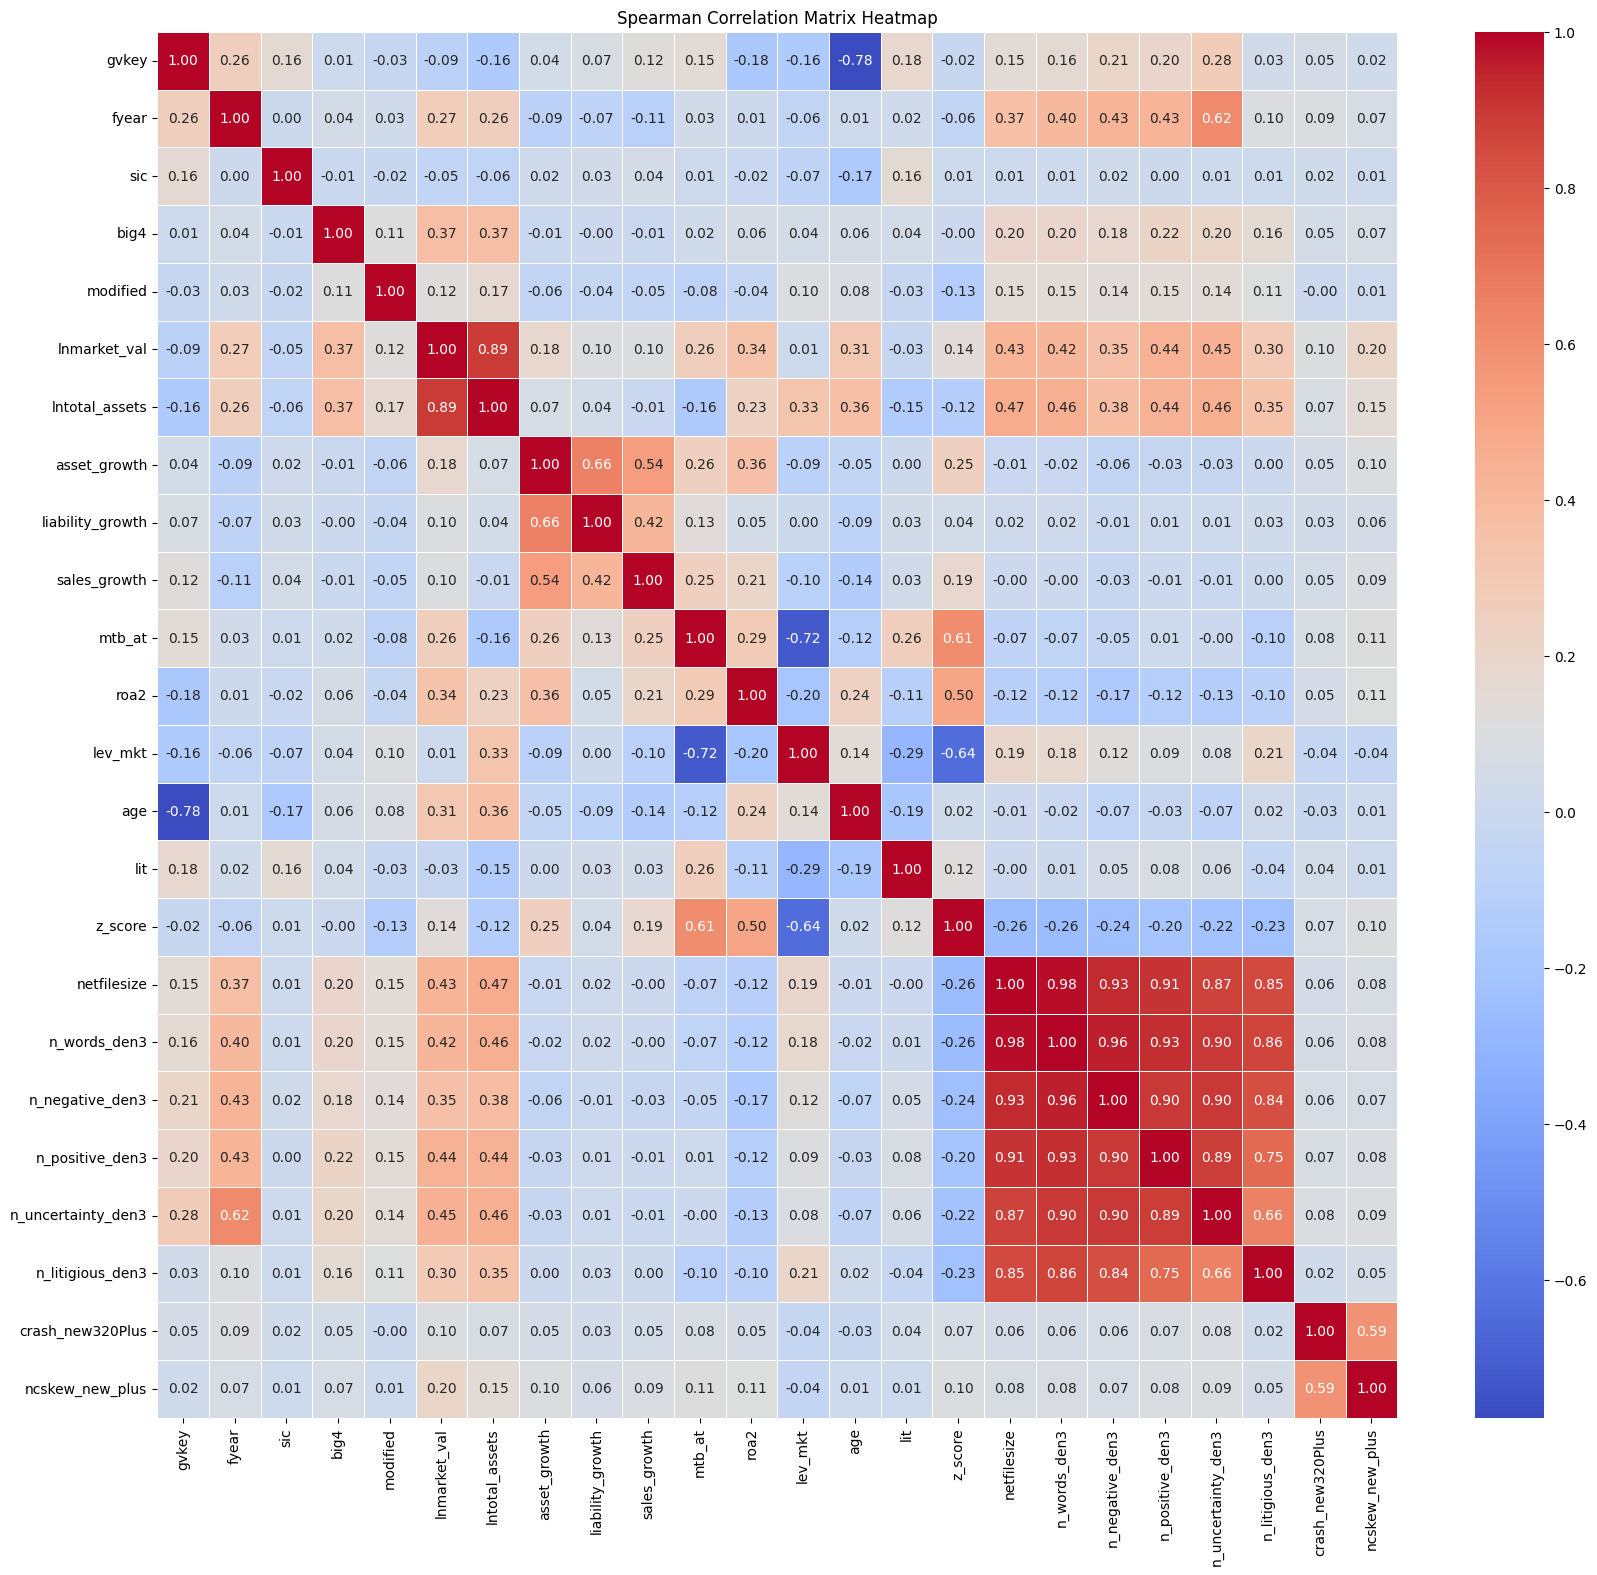

In [49]:

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar=True, linewidths=0.5)
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()


#In the Spearman correlation test:

#Correlation coefficient (ρ, rho): Measures the strength and direction of the monotonic relationship between two variables.

#ρ = +1 → Perfect positive correlation
#ρ = -1 → Perfect negative correlation
#ρ = 0 → No correlation
#p-value: Indicates the significance of the correlation.

#Low p-value (e.g., < 0.05) → Statistically significant correlation
#High p-value (e.g., > 0.05) → No significant correlation






